<a href="https://colab.research.google.com/github/Zheleikina/ML/blob/main/%D0%9B%D0%A02_1_%D0%96%D0%B5%D0%BB%D0%B5%D0%B9%D0%BA%D1%96%D0%BD%D0%B0_3_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

:Лабораторна робота 2. Желейкіна, 3-9

# Завдання 1

**Була присутня на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

In [44]:
import pandas as pd
import numpy as np
import requests

1. Вивести перші 5 рядків датасета

In [45]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)  # зчитати всі таблиці
df = tables[2]  # потрібна таблиця (може змінюватись!), номери не є сталими!
df.head()

/tmp/ipykernel_800/2672163494.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)  # зчитати всі таблиці


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [46]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [48]:
df.columns = (df.columns
    .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
    .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [49]:
df = df.drop(df[df.iloc[:, 0] == "world"].index)
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [50]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [51]:
# Convert columns to float type
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')


In [52]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [53]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [54]:
# Replace NaN with mean of the row. Ignore first column (Country)
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)
df.isnull().sum()

,0
Country,0
IMF (2026),8
World Bank (2025),8
United Nations (2024),8


In [55]:
part = df.iloc[:, 1:]

row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()

df.iloc[:, 1:] = row_filled.fillna(col_means)
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [56]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024)
212,Saint Martin,1.181726e+06,1.106580e+06,1.043505e+06
213,Federated States of Micronesia,5.210000e+02,5.020000e+02,4.710000e+02
214,Anguilla,4.560000e+02,4.560000e+02,4.560000e+02
215,Cook Islands,4.140000e+02,4.140000e+02,4.140000e+02
216,Kiribati,4.010000e+02,3.490000e+02,3.430000e+02
217,Palau,3.770000e+02,3.450000e+02,3.100000e+02
218,Marshall Islands,3.420000e+02,3.080000e+02,2.810000e+02
219,Nauru,1.960000e+02,1.760000e+02,1.870000e+02
220,Montserrat,8.100000e+01,8.100000e+01,8.100000e+01
221,Tuvalu,6.500000e+01,5.700000e+01,5.600000e+01


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [57]:
# Check for duplicates and drop them
df.duplicated().sum()

np.int64(0)

In [58]:
#df.drop_duplicates(inplace=True)

7.	Вивести описову статистику датасету describe()

In [59]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.181726e+06,1.106580e+06,1.043505e+06
std,8.847522e+06,8.297770e+06,7.830342e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.638250e+03,9.642125e+03,9.170750e+03
50%,5.024150e+04,4.835900e+04,4.322450e+04
75%,3.798190e+05,3.436938e+05,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [61]:
# Count difference between IMF_Forecast and WB_Estimate for each country
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

# Find which country has the largest difference between IMF and WB
max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

World has the largest difference between IMF and WB: 7945165.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
0,World,126295331.0,118350166.0,111565144.0,7945165.0
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [62]:
# Calculate correlation between IMF and WB and UN
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9999854383994787
Correlation between IMF and UN: 0.9999656762678483
Correlation between WB and UN: 0.9999814895719566


In [63]:
# Find highest correlation
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [64]:
# Find mean of IMF, WB and UN
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(1181726.3364485982)

In [65]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(1106580.2710280374)

In [66]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN

np.float64(1043504.668224299)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [67]:
# Find standard deviation for each row
df['std'] = df.iloc[:, 1:].std(axis=1)

# Find country with the highest standard deviation
max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

World has the highest standard deviation: 55721978.507490404


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [68]:
# Find max and min GDP for each year
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df['United Nations (2024)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 126295331.0, Min IMF: 65.0
Max WB: 118350166.0, Min WB: 57.0
Max UN: 111565144.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

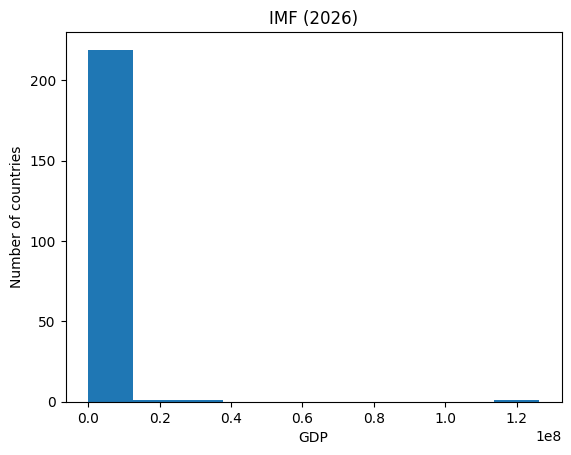

In [69]:
import matplotlib.pyplot as plt

# Build a histogram of IMF_Forecast
plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

Розподіл ВВП є правобічно асиметричним із зосередженням більшості країн у нижньому діапазоні значень, тоді як США та Китай різко виділяються як глобальні лідери-екстремуми у правому хвості.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [72]:
# Calculate share of world GDP for each country for each year
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07,0.481413,0.481762,0.481594
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.123441,0.125253,0.126471
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.079482,0.079370,0.080912
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.020785,0.020561,0.020116
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.016693,0.018054,0.017380
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.016257,0.016293,0.015911
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.015831,0.016104,0.017061
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.013708,0.013703,0.013643
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.010437,0.010387,0.010277
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.010126,0.010426,0.009382


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [73]:
# Find top 10 countries with the most significant change in share of world GDP between IMF and UN
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10 = df.nlargest(10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.123441,0.125253,0.126471,0.003030
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.079482,0.079370,0.080912,0.001429
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.015831,0.016104,0.017061,0.001230
53,Iran,300293.0,362682.0,448092.0,62389.0,1.654723e+05,0.001145,0.001476,0.001934,0.000790
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.010126,0.010426,0.009382,0.000744
15,South Korea,1931008.0,1872375.0,1875388.0,58633.0,9.175414e+05,0.007361,0.007622,0.008096,0.000735
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.016693,0.018054,0.017380,0.000687
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.020785,0.020561,0.020116,0.000670
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.010048,0.009281,0.009436,0.000612
16,Turkey,1640223.0,1597293.0,1323255.0,42930.0,7.518882e+05,0.006252,0.006502,0.005712,0.000540


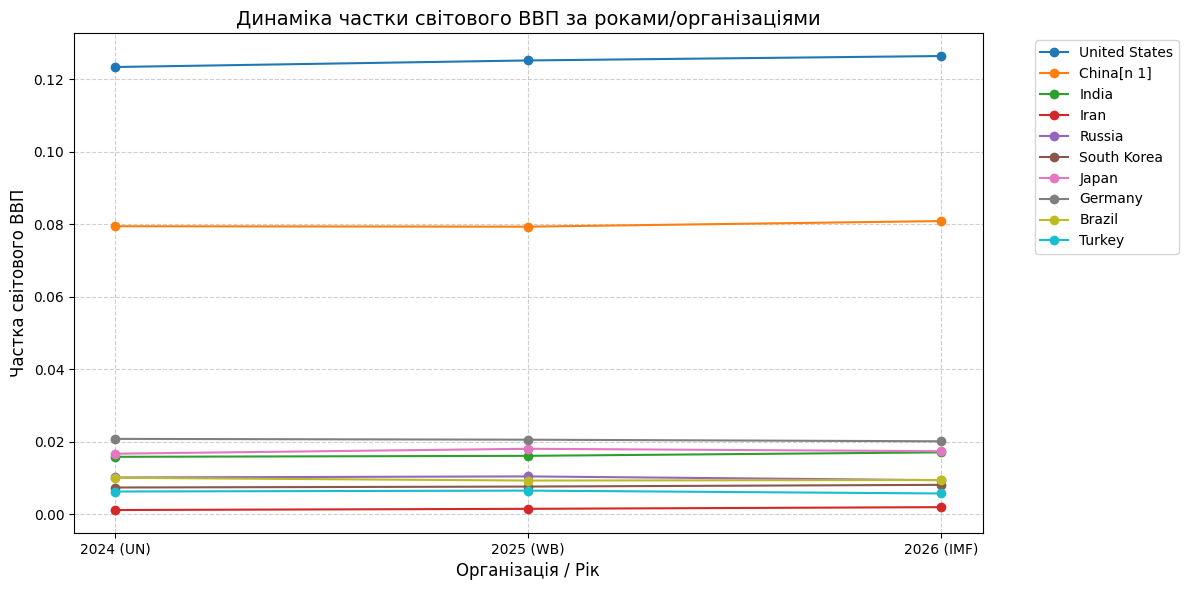

Кількість країн із тенденцією до зростання: 126
Кількість країн із тенденцією до спаду: 88


In [74]:
years_cols = ['IMF_Share', 'WB_Share', 'UN_Share']

# 2. Побудова графіка динаміки для кожної країни (для прикладу беремо топ-10 країн за різницею або топ за ВВП)
plt.figure(figsize=(12, 6))

for idx, row in df_top10.iterrows():
  country_name = row['Country']
  values = [row['IMF_Share'], row['WB_Share'], row['UN_Share']]
  plt.plot(['2024 (UN)', '2025 (WB)', '2026 (IMF)'], values, marker='o', label=country_name)

plt.title('Динаміка частки світового ВВП за роками/організаціями', fontsize=14)
plt.xlabel('Організація / Рік', fontsize=12)
plt.ylabel('Частка світового ВВП', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Аналіз трендів (стабільне зростання або спад)
# Порівнюємо значення між першою (UN 2024) та останньою (IMF 2026) точками
df['Trend_Diff'] = df['IMF_Share'] - df['UN_Share']

# Стабільне зростання (показник послідовно зростав або загальна різниця > 0)
growing_countries = df[df['Trend_Diff'] > 0]['Country'].tolist()
# Стабільний спад (загальна різниця < 0)
declining_countries = df[df['Trend_Diff'] < 0]['Country'].tolist()

print(f"Кількість країн із тенденцією до зростання: {len(growing_countries)}")
print(f"Кількість країн із тенденцією до спаду: {len(declining_countries)}")

Під час роботи було виконано очищення, аналіз та візуалізацію даних. Було оброблено пропущені значення, знайдено статистичні показники, кореляції та викиди. Також створено нові ознаки та визначено країни з найбільшими показниками ВВП.



У результаті було отримано практичні навички роботи з даними та їх аналізу за допомогою Python.

